In [1]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

pd.options.display.max_columns = 50

In [2]:
import Go_tools

In [3]:
# metadata = pd.read_csv(
#     "/Users/michael/Data/Luke_terrace_experiment/General_data/Plates_1_to_5_metadata_merged_luke.csv",
#     index_col=0,
# )
# metadata = metadata.drop(
#     columns=[
#         "arb.sort",
#         "sample-id",
#         "Ambiguous Unstranded",
#         "Ambiguous Forward",
#         "Multimapping",
#         "Unmapped Over Mapped",
#     ]
# )
# metadata["Date and Time"] = metadata["date"] + " " + metadata["time"]
# luke_time_data_format = "%-m/%-d/%y %-H:%-M"
# metadata["Date and Time"] = pd.to_datetime(
#     metadata["Date and Time"], format=luke_time_data_format
# )

In [4]:
microbiome_abundance = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Sept_2026_recalled_genera/lic_16S_gen_rab_clean.csv"
)
long_term_microbiome = microbiome_abundance.loc[
    (microbiome_abundance["sample.type"] == "plant")
    & (microbiome_abundance["seascirc"] == "seasonal")
]
long_term_microbiome = long_term_microbiome.rename(columns={"Sample": "sampID"})
long_term_microbiome

,OTU,sampID,Abundance,sample.type,timepoint,platename,daysincestart,n,day,time,Temperature,avgPrecipCm,snow,tempDailyAvg,seascirc,sampsums,Kingdom,Phylum,Class,Order,Family,Genus,AbundR
1,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,LIC063,688.058093,plant,t06,LIC_01,27,1,11/28/23,8:00,3.062,0.000000,none,2.318519,seasonal,38972,d__Bacteria,p__Pseudomonadota,c__Alphaproteobacteria,o__Sphingomonadales,f__Sphingomonadaceae_486827,g__Sphingomonas,688
3,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,LIC016,630.663054,plant,t02,LIC_01,6,1,11/7/23,8:00,14.000,0.190000,none,15.137037,seasonal,23618,d__Bacteria,p__Pseudomonadota,c__Alphaproteobacteria,o__Sphingomonadales,f__Sphingomonadaceae_486827,g__Sphingomonas,631
4,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,LIC015,586.702747,plant,t02,LIC_01,6,1,11/7/23,8:00,14.000,0.190000,none,15.137037,seasonal,31781,d__Bacteria,p__Pseudomonadota,c__Alphaproteobacteria,o__Sphingomonadales,f__Sphingomonadaceae_486827,g__Sphingomonas,587
5,d__Bacteria;p__Cyanobacteriota;c__Cyanobacteri...,LIC159,554.963660,plant,t14,LIC_02,83,1,1/23/24,8:00,0.548,0.103333,snow,3.233333,seasonal,24216,d__Bacteria,p__Cyanobacteriota,c__Cyanobacteriia,o__Cyanobacteriales,f__Coleofasciculaceae,g__Caldora,555
8,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,LIC306,513.686303,plant,t26,LIC_04,128,1,3/8/24,8:00,9.089,0.456667,none,8.162963,seasonal,37227,d__Bacteria,p__Pseudomonadota,c__Alphaproteobacteria,o__Sphingomonadales,f__Sphingomonadaceae_486827,g__Sphingomonas,514
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33501,d__Bacteria;p__Actinomycetota;c__Actinomycetes...,LIC176,0.500375,plant,t15,LIC_02,87,1,1/27/24,8:00,6.579,0.646667,none,7.066667,seasonal,27979,d__Bacteria,p__Actinomycetota,c__Actinomycetes,o__Mycobacteriales,f__Mycobacteriaceae,g__Williamsia,1
33502,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,LIC176,0.500375,plant,t15,LIC_02,87,1,1/27/24,8:00,6.579,0.646667,none,7.066667,seasonal,27979,d__Bacteria,p__Pseudomonadota,c__Alphaproteobacteria,o__Rhizobiales_505101,f__Rhizobiaceae,g__Pararhizobium,1
33503,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,LIC235,0.500375,plant,t20,LIC_03,107,1,2/16/24,8:00,1.554,0.186667,snow,4.203704,seasonal,7994,d__Bacteria,p__Pseudomonadota,c__Gammaproteobacteria,o__Burkholderiales,f__Rhodocyclaceae,g__Dactylopiibacterium,1
33504,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,LIC234,0.500367,plant,t20,LIC_03,107,1,2/16/24,8:00,1.554,0.186667,snow,4.203704,seasonal,29978,d__Bacteria,p__Pseudomonadota,c__Alphaproteobacteria,o__Rhizobiales_505101,f__Rhizobiaceae,g__Rhizobium,1


In [5]:
long_term_microbiome["sample.type"].unique()

array(['plant'], dtype=object)

In [6]:
# Quick peek at columns / IDs
print("rows:", len(long_term_microbiome))
print(
    "unique sampID:",
    (
        long_term_microbiome["sampID"].nunique()
        if "sampID" in long_term_microbiome.columns
        else "(no sampID col)"
    ),
)
print("columns:")
print(list(long_term_microbiome.columns))
long_term_microbiome.head()

rows: 15117
unique sampID: 222
columns:
['OTU', 'sampID', 'Abundance', 'sample.type', 'timepoint', 'platename', 'daysincestart', 'n', 'day', 'time', 'Temperature', 'avgPrecipCm', 'snow', 'tempDailyAvg', 'seascirc', 'sampsums', 'Kingdom', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'AbundR']


,OTU,sampID,Abundance,sample.type,timepoint,platename,daysincestart,n,day,time,Temperature,avgPrecipCm,snow,tempDailyAvg,seascirc,sampsums,Kingdom,Phylum,Class,Order,Family,Genus,AbundR
1,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,LIC063,688.058093,plant,t06,LIC_01,27,1,11/28/23,8:00,3.062,0.000000,none,2.318519,seasonal,38972,d__Bacteria,p__Pseudomonadota,c__Alphaproteobacteria,o__Sphingomonadales,f__Sphingomonadaceae_486827,g__Sphingomonas,688
3,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,LIC016,630.663054,plant,t02,LIC_01,6,1,11/7/23,8:00,14.000,0.190000,none,15.137037,seasonal,23618,d__Bacteria,p__Pseudomonadota,c__Alphaproteobacteria,o__Sphingomonadales,f__Sphingomonadaceae_486827,g__Sphingomonas,631
4,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,LIC015,586.702747,plant,t02,LIC_01,6,1,11/7/23,8:00,14.000,0.190000,none,15.137037,seasonal,31781,d__Bacteria,p__Pseudomonadota,c__Alphaproteobacteria,o__Sphingomonadales,f__Sphingomonadaceae_486827,g__Sphingomonas,587
5,d__Bacteria;p__Cyanobacteriota;c__Cyanobacteri...,LIC159,554.963660,plant,t14,LIC_02,83,1,1/23/24,8:00,0.548,0.103333,snow,3.233333,seasonal,24216,d__Bacteria,p__Cyanobacteriota,c__Cyanobacteriia,o__Cyanobacteriales,f__Coleofasciculaceae,g__Caldora,555
8,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,LIC306,513.686303,plant,t26,LIC_04,128,1,3/8/24,8:00,9.089,0.456667,none,8.162963,seasonal,37227,d__Bacteria,p__Pseudomonadota,c__Alphaproteobacteria,o__Sphingomonadales,f__Sphingomonadaceae_486827,g__Sphingomonas,514


In [7]:
long_term_microbiome.to_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Generated_data/recalled_plant_full_microbiome.csv",
    index=False,
)

In [8]:
long_term_microbiome.iloc[0][0]

/var/folders/nk/6xkk9sgn1pz4ff1b36sfq3y40000gt/T/ipykernel_17663/701326328.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  long_term_microbiome.iloc[0][0]


'd__Bacteria;p__Pseudomonadota;c__Alphaproteobacteria;o__Sphingomonadales;f__Sphingomonadaceae_486827;g__Sphingomonas_L_486704'

In [9]:
def core_taxa_table(
    df: pd.DataFrame,
    tax_col: str,
    sample_col: str = "sampID",
    abundance_col: str = "AbundR100",
    core_threshold: float = 0.80,
    drop_unassigned: bool = True,
    unassigned_labels: tuple[str, ...] = ("unassigned", "na", "none", ""),
) -> pd.DataFrame:
    """Return a table of prevalence and core status for a given taxonomic rank.

        Prevalence is defined as:
    # unique samples where the taxon is present / total unique samples in df
    """
    if sample_col not in df.columns:
        raise KeyError(f"{sample_col!r} not found in df")
    if tax_col not in df.columns:
        raise KeyError(f"{tax_col!r} not found in df")

    total_samples = df[sample_col].dropna().nunique()
    if total_samples == 0:
        raise ValueError("No samples found in df; cannot compute prevalence")

    keep_cols = [sample_col, tax_col] + (
        [abundance_col] if abundance_col in df.columns else []
    )
    working = df[keep_cols].copy()

    # Preserve missing values while still allowing string ops like strip/lower
    working[tax_col] = working[tax_col].astype("string").str.strip()

    if drop_unassigned:
        # Drop missing/blank/unassigned labels (case-insensitive)
        labels = {s.casefold() for s in unassigned_labels}
        working = working[working[tax_col].notna()]
        series_cf = working[tax_col].str.casefold()
        working = working[~series_cf.isin(labels)]

    grouped = working.groupby(tax_col, dropna=False)
    out = grouped.agg(
        n_samples_present=(sample_col, "nunique"),
        mean_abundance_present=(
            (abundance_col, "mean")
            if abundance_col in working.columns
            else (sample_col, "size")
        ),
        median_abundance_present=(
            (abundance_col, "median")
            if abundance_col in working.columns
            else (sample_col, "size")
        ),
    ).reset_index()

    if abundance_col not in working.columns:
        out = out.rename(columns={"mean_abundance_present": "rows_present"})
        out = out.drop(columns=["median_abundance_present"], errors="ignore")

    out["prevalence"] = out["n_samples_present"] / total_samples
    out["core"] = out["prevalence"] > core_threshold
    out = out.sort_values(
        ["core", "prevalence", "n_samples_present"], ascending=[False, False, False]
    )
    out = out.reset_index(drop=True)
    return out

In [10]:
core_threshold = 0.80
tax_ranks = ["Genus", "Family", "Order"]

core_results = {}
for rank in tax_ranks:
    tbl = core_taxa_table(
        long_term_microbiome,
        tax_col=rank,
        sample_col="sampID",
        abundance_col="AbundR100",
        core_threshold=core_threshold,
        drop_unassigned=True,
    )
    core_tbl = tbl[tbl["core"]].copy()
    noncore_tbl = tbl[~tbl["core"]].copy()

    core_results[rank] = {"all": tbl, "core": core_tbl, "noncore": noncore_tbl}

    print(f"\n=== {rank} ===")
    print(f"Total taxa: {len(tbl)}")
    print(f"Core taxa (prevalence > {core_threshold:.0%}): {len(core_tbl)}")
    if len(core_tbl) > 0:
        display(core_tbl.head(25))
    else:
        print("(No core taxa at this rank)")


=== Genus ===
Total taxa: 263
Core taxa (prevalence > 80%): 36


,Genus,n_samples_present,rows_present,prevalence,core
0,g__Flavobacterium,222,222,1.000000,True
1,g__Friedmanniella,222,222,1.000000,True
2,g__Klenkia,222,222,1.000000,True
3,g__Kordiimonas,222,222,1.000000,True
4,g__Massilia,222,222,1.000000,True
5,g__Methylobacterium,222,222,1.000000,True
6,g__Neorhizobium,222,222,1.000000,True
7,g__Nocardioides,222,222,1.000000,True
8,g__Pseudomonas,222,222,1.000000,True
9,g__Rhodoferax,222,222,1.000000,True



=== Family ===
Total taxa: 104
Core taxa (prevalence > 80%): 21


,Family,n_samples_present,rows_present,prevalence,core
0,f__Beijerinckiaceae,222,514,1.000000,True
1,f__Burkholderiaceae_A_595421,222,4067,1.000000,True
2,f__Flavobacteriaceae,222,222,1.000000,True
3,f__Geodermatophilaceae,222,641,1.000000,True
4,f__Kordiimonadaceae,222,222,1.000000,True
5,f__Microbacteriaceae,222,1164,1.000000,True
6,f__Mycobacteriaceae,222,394,1.000000,True
7,f__Nocardioidaceae,222,630,1.000000,True
8,f__Propionibacteriaceae,222,320,1.000000,True
9,f__Pseudomonadaceae,222,222,1.000000,True



=== Order ===
Total taxa: 58
Core taxa (prevalence > 80%): 11


,Order,n_samples_present,rows_present,prevalence,core
0,o__Actinomycetales,222,1789,1.000000,True
1,o__Burkholderiales,222,4492,1.000000,True
2,o__Flavobacteriales_B_877923,222,427,1.000000,True
3,o__Mycobacteriales,222,2187,1.000000,True
4,o__Propionibacteriales,222,959,1.000000,True
5,o__Pseudomonadales_A_650611,222,222,1.000000,True
6,o__Rhizobiales_505101,222,1961,1.000000,True
7,o__Sphingomonadales,222,674,1.000000,True
8,o__Caulobacterales,212,391,0.954955,True
9,o__Solirubrobacterales,210,463,0.945946,True


In [11]:
# Core size as a function of required samples-present threshold
total_samples = long_term_microbiome["sampID"].dropna().nunique()
thresholds = np.arange(0, total_samples + 1)  # required #samples present

# If you ever want strict ">" semantics instead of ">=", flip this to True
strictly_greater_than_threshold = False

rank_tables = {}
for rank in tax_ranks:
    # Prefer the already-computed tables, but fall back if needed
    tbl = None
    if (
        "core_results" in globals()
        and rank in core_results
        and "all" in core_results[rank]
    ):
        tbl = core_results[rank]["all"]
    else:
        tbl = core_taxa_table(
            long_term_microbiome, tax_col=rank, core_threshold=core_threshold
        )
    rank_tables[rank] = tbl

core_count_curve = pd.DataFrame({"required_n_samples": thresholds})
core_count_curve["required_prevalence"] = (
    core_count_curve["required_n_samples"] / total_samples
)

for rank, tbl in rank_tables.items():
    present_counts = tbl["n_samples_present"].to_numpy()
    if strictly_greater_than_threshold:
        counts = np.array([(present_counts > t).sum() for t in thresholds], dtype=int)
    else:
        counts = np.array([(present_counts >= t).sum() for t in thresholds], dtype=int)
    core_count_curve[f"n_{rank.lower()}_core"] = counts

core_count_curve

,required_n_samples,required_prevalence,n_genus_core,n_family_core,n_order_core
0,0,0.000000,263,104,58
1,1,0.004505,263,104,58
2,2,0.009009,226,95,51
3,3,0.013514,203,83,47
4,4,0.018018,189,80,46
...,...,...,...,...,...
218,218,0.981982,20,16,8
219,219,0.986486,16,15,8
220,220,0.990991,16,14,8
221,221,0.995495,13,12,8


In [12]:
melted_core_count = core_count_curve[
    [
        "required_prevalence",
        "n_genus_core",
        "n_family_core",
        "n_order_core",
    ]
].melt(
    id_vars="required_prevalence",
)

In [13]:
melted_core_count

,required_prevalence,variable,value
0,0.000000,n_genus_core,263
1,0.004505,n_genus_core,263
2,0.009009,n_genus_core,226
3,0.013514,n_genus_core,203
4,0.018018,n_genus_core,189
...,...,...,...
664,0.981982,n_order_core,8
665,0.986486,n_order_core,8
666,0.990991,n_order_core,8
667,0.995495,n_order_core,8


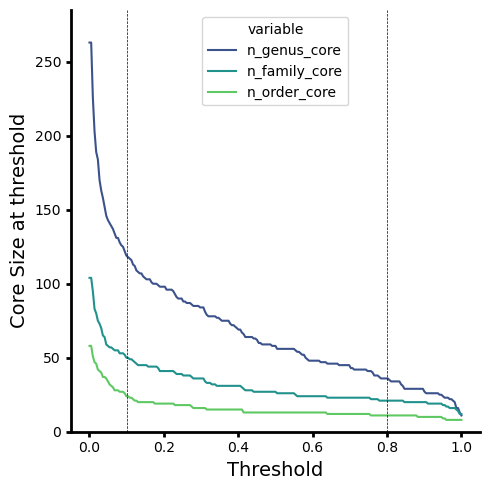

In [14]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
ax = sns.lineplot(
    data=melted_core_count,
    x="required_prevalence",
    y="value",
    hue="variable",
    palette="viridis",
)
plt.xlabel("Threshold", fontsize=14)
plt.ylabel("Core Size at threshold", fontsize=14)
sns.despine()
# ax.grid(False)
plt.axvline(0.1, color="k", linestyle="dashed", linewidth=0.5)
plt.axvline(0.8, color="k", linestyle="dashed", linewidth=0.5)
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
# plt.xlim((0,3))
plt.ylim((0, 285))
# handles, labels  =  ax.get_legend_handles_labels()
# ax.legend(loc="upper right")
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(
    fontsize=10,
)  # rotation=90
plt.yticks(fontsize=10)

# plt.ylim(-.02,1)
plt.tight_layout()
# ax.plot([0,1],[0,1], transform=ax.transAxes, linestyle = 'dashed', color = 'k', linewidth = 1.5)
# for line in range(0,full_meta_data.shape[0]):
#      ax.text(pca[:,0][line]+0.01, pca[:,1][line],
#      full_meta_data['plate.pos'][line], horizontalalignment='left',
#      size='medium', color='black', weight='semibold')

In [15]:
# asv_table = pd.read_csv(
#     "/Users/michael/Data/Luke_terrace_experiment/Microbiome/lic2024_asvtable.txt",
#     sep="\t",
#     index_col=0,
# )

In [16]:
# # Core size vs threshold including the ASV level from the new ASV table
# # ASV table is wide (asvID x sample); restrict to the same samples used above so
# # prevalence uses an identical denominator to the taxonomic ranks.
# asv_samples = [
#     c for c in asv_table.columns if c in set(long_term_microbiome["sampID"].dropna())
# ]
# print(
#     f"ASV table samples matched to long_term_microbiome: {len(asv_samples)} / {total_samples}"
# )

# asv_present_counts = (asv_table[asv_samples] > 0).sum(axis=1).to_numpy()
# asv_present_counts = asv_present_counts[
#     asv_present_counts > 0
# ]  # drop ASVs absent from these samples

# core_count_curve_asv = core_count_curve.copy()
# if strictly_greater_than_threshold:
#     core_count_curve_asv["n_asv_core"] = [
#         int((asv_present_counts > t).sum()) for t in thresholds
#     ]
# else:
#     core_count_curve_asv["n_asv_core"] = [
#         int((asv_present_counts >= t).sum()) for t in thresholds
#     ]

# melted_core_count_asv = core_count_curve_asv[
#     [
#         "required_prevalence",
#         "n_asv_core",
#         "n_species_core",
#         "n_genus_core",
#         "n_family_core",
#         "n_order_core",
#     ]
# ].melt(
#     id_vars="required_prevalence",
# )

# fig, ax = plt.subplots(figsize=(5, 5))
# fig.patch.set_facecolor("white")
# ax = sns.lineplot(
#     data=melted_core_count_asv,
#     x="required_prevalence",
#     y="value",
#     hue="variable",
#     palette="viridis",
# )
# plt.xlabel("Threshold", fontsize=14)
# plt.ylabel("Core Size at threshold", fontsize=14)
# sns.despine()
# plt.axvline(0.1, color="k", linestyle="dashed", linewidth=0.5)
# plt.axvline(0.8, color="k", linestyle="dashed", linewidth=0.5)
# ax.spines["bottom"].set_color("black")
# ax.spines["bottom"].set_linewidth(2)
# ax.spines["left"].set_color("black")
# ax.spines["left"].set_linewidth(2)
# ax.tick_params(axis="both", width=2)
# plt.ylim((0, melted_core_count_asv["value"].max() * 1.05))
# plt.xticks(
#     fontsize=10,
# )
# plt.yticks(fontsize=10)
# plt.tight_layout()

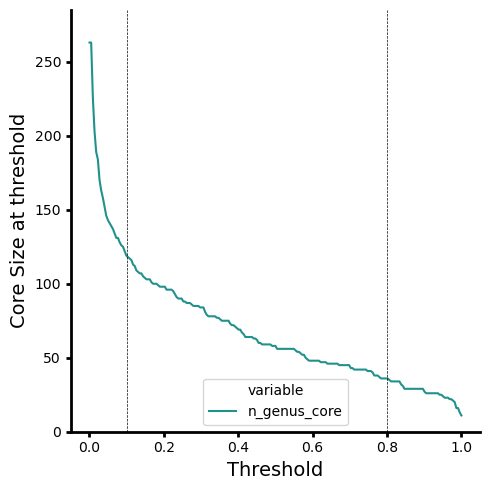

In [17]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
ax = sns.lineplot(
    data=melted_core_count.loc[melted_core_count["variable"] == "n_genus_core"],
    x="required_prevalence",
    y="value",
    hue="variable",
    palette="viridis",
)
plt.xlabel("Threshold", fontsize=14)
plt.ylabel("Core Size at threshold", fontsize=14)
sns.despine()
# ax.grid(False)
plt.axvline(0.1, color="k", linestyle="dashed", linewidth=0.5)
plt.axvline(0.8, color="k", linestyle="dashed", linewidth=0.5)
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
# plt.xlim((0,3))
plt.ylim((0, 285))
# handles, labels  =  ax.get_legend_handles_labels()
# ax.legend(loc="upper right")
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(
    fontsize=10,
)  # rotation=90
plt.yticks(fontsize=10)

# plt.ylim(-.02,1)
plt.tight_layout()
# ax.plot([0,1],[0,1], transform=ax.transAxes, linestyle = 'dashed', color = 'k', linewidth = 1.5)
# for line in range(0,full_meta_data.shape[0]):
#      ax.text(pca[:,0][line]+0.01, pca[:,1][line],
#      full_meta_data['plate.pos'][line], horizontalalignment='left',
#      size='medium', color='black', weight='semibold')

In [18]:
#### Questions: When do rare genus show up? Are they evenly distributed or do they all show up late?

In [19]:
genus_core_results = core_results["Genus"]["all"]
genus_core_results

,Genus,n_samples_present,rows_present,prevalence,core
0,g__Flavobacterium,222,222,1.000000,True
1,g__Friedmanniella,222,222,1.000000,True
2,g__Klenkia,222,222,1.000000,True
3,g__Kordiimonas,222,222,1.000000,True
4,g__Massilia,222,222,1.000000,True
...,...,...,...,...,...
258,g__Umezawaea,1,1,0.004505,False
259,g__VFKE01,1,1,0.004505,False
260,g__Variibacter,1,1,0.004505,False
261,g__WHSN01,1,1,0.004505,False


In [20]:
genus_core_results.to_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Generated_data/recalled_genus_core_results.csv",
    index=False,
)

In [21]:
rare_genus = genus_core_results.loc[genus_core_results["prevalence"] < 0.1]
rare_genus

,Genus,n_samples_present,rows_present,prevalence,core
118,g__Alteriqipengyuania,22,22,0.099099,False
119,f__Bryobacteraceae Family,21,21,0.094595,False
120,g__Poseidonocella,21,21,0.094595,False
121,g__Stenotrophomonas,21,21,0.094595,False
122,g__Asticcacaulis,20,20,0.090090,False
...,...,...,...,...,...
258,g__Umezawaea,1,1,0.004505,False
259,g__VFKE01,1,1,0.004505,False
260,g__Variibacter,1,1,0.004505,False
261,g__WHSN01,1,1,0.004505,False


In [22]:
# rare_genus.to_csv(
#     "/Users/michael/Data/Luke_terrace_experiment/General_data/Generated_data/rare_genus_long_term_plant.csv",
#     index=False,
# )

In [23]:
# Count rare genus observed at each timepoint
rare_genus_set = set(rare_genus["Genus"].dropna().astype(str))

# Filter long_term_microbiome down to rare genus rows (these rows imply presence)
rare_occurrences = long_term_microbiome.loc[
    long_term_microbiome["Genus"].astype(str).isin(rare_genus_set),
    ["sampID", "timepoint", "day", "Genus", "AbundR"],
].copy()

# Summarize by timepoint
rare_genus_by_timepoint = (
    rare_occurrences.groupby("timepoint", dropna=False)
    .agg(
        n_samples=("sampID", "nunique"),
        n_unique_rare_genus=("Genus", "nunique"),
        n_rare_occurrences=("Genus", "size"),
        first_date=("day", "min"),
        last_date=("day", "max"),
    )
    .reset_index()
    .sort_values("timepoint")
    .reset_index(drop=True)
)

rare_genus_by_timepoint

,timepoint,n_samples,n_unique_rare_genus,n_rare_occurrences,first_date,last_date
0,t01,8,22,32,11/1/23,11/1/23
1,t02,8,41,57,11/7/23,11/7/23
2,t03,8,18,24,11/14/23,11/14/23
3,t04,8,27,29,11/17/23,11/17/23
4,t05,7,30,32,11/21/23,11/21/23
5,t06,8,26,31,11/28/23,11/28/23
6,t07,7,33,38,12/1/23,12/1/23
7,t08,6,14,15,12/5/23,12/5/23
8,t09,7,23,34,12/8/23,12/8/23
9,t10,8,30,40,12/12/23,12/12/23


In [24]:
# Get core genus from pre-computed results
core_genus = core_results["Genus"]["core"]
core_genus_set = set(core_genus["Genus"].dropna().astype(str))

# For each sample, find which core genus are present
sample_genus = (
    long_term_microbiome.loc[
        long_term_microbiome["Genus"].astype(str).isin(core_genus_set),
        ["sampID", "timepoint", "day", "Genus"],
    ]
    .drop_duplicates()
    .copy()
)

# Get all unique samples with their timepoints
all_samples = long_term_microbiome[["sampID", "timepoint", "day"]].drop_duplicates()

# For each sample, count how many core genus are missing
n_core = len(core_genus_set)
sample_core_counts = sample_genus.groupby("sampID")["Genus"].nunique().reset_index()
sample_core_counts.columns = ["sampID", "n_core_present"]

# Merge with all samples to get timepoint info
sample_core_summary = all_samples.merge(sample_core_counts, on="sampID", how="left")
sample_core_summary["n_core_present"] = (
    sample_core_summary["n_core_present"].fillna(0).astype(int)
)
sample_core_summary["n_core_missing"] = n_core - sample_core_summary["n_core_present"]
sample_core_summary["missing_any_core"] = sample_core_summary["n_core_missing"] > 0

# Summarize by timepoint
missing_core_by_timepoint = (
    sample_core_summary.groupby("timepoint", dropna=False)
    .agg(
        n_samples=("sampID", "nunique"),
        n_samples_missing_any_core=("missing_any_core", "sum"),
        total_core_missing=("n_core_missing", "sum"),
        mean_core_missing=("n_core_missing", "mean"),
        first_date=("day", "min"),
        last_date=("day", "max"),
    )
    .reset_index()
    .sort_values("timepoint")
    .reset_index(drop=True)
)

print(f"Total core genus (prevalence > {core_threshold:.0%}): {n_core}")
missing_core_by_timepoint

Total core genus (prevalence > 80%): 36


,timepoint,n_samples,n_samples_missing_any_core,total_core_missing,mean_core_missing,first_date,last_date
0,t01,8,6,13,1.625000,11/1/23,11/1/23
1,t02,8,8,16,2.000000,11/7/23,11/7/23
2,t03,8,5,11,1.375000,11/14/23,11/14/23
3,t04,8,8,25,3.125000,11/17/23,11/17/23
4,t05,8,6,12,1.500000,11/21/23,11/21/23
5,t06,8,7,17,2.125000,11/28/23,11/28/23
6,t07,8,7,16,2.000000,12/1/23,12/1/23
7,t08,8,7,19,2.375000,12/5/23,12/5/23
8,t09,8,8,34,4.250000,12/8/23,12/8/23
9,t10,8,8,26,3.250000,12/12/23,12/12/23


In [25]:
# Compare core / rare genera from the new recalled-genera table to the old
# (pre-recall) results. Old names carry GTDB suffixes (e.g. "Sphingomonas_L_486704")
# and new names a "g__" prefix, so both are normalised to a bare genus name.
# Note: several old suffixed genera collapse into one name (149 -> 128).
import re

old_genus_results = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Generated_data/genus_core_results.csv"
)


def normalise_genus(name):
    name = re.sub(r"^g__", "", str(name).strip())
    return re.sub(r"(_[A-Z]{1,2})?(_\d+)?$", "", name)


def classify(prevalence):
    return np.select(
        [prevalence > core_threshold, prevalence < 0.1],
        ["Core", "Rare"],
        default="Accessory",
    )


old_classes = old_genus_results.assign(
    genus_norm=old_genus_results["Genus"].map(normalise_genus),
    old_class=lambda df: classify(df["prevalence"]),
)
new_classes = genus_core_results.assign(
    genus_norm=genus_core_results["Genus"].map(normalise_genus),
    new_class=lambda df: classify(df["prevalence"]),
)

genus_class_comparison = []
for cls in ["Core", "Rare"]:
    old_set = set(old_classes.loc[old_classes["old_class"] == cls, "genus_norm"])
    new_set = set(new_classes.loc[new_classes["new_class"] == cls, "genus_norm"])
    genus_class_comparison.append(
        {
            "class": cls,
            "n_old": len(old_set),
            "n_new": len(new_set),
            "n_shared": len(old_set & new_set),
            "n_old_only": len(old_set - new_set),
            "n_new_only": len(new_set - old_set),
            "jaccard": len(old_set & new_set) / len(old_set | new_set),
            "shared": sorted(old_set & new_set),
            "old_only": sorted(old_set - new_set),
            "new_only": sorted(new_set - old_set),
        }
    )
genus_class_comparison = pd.DataFrame(genus_class_comparison).set_index("class")
display(
    genus_class_comparison.drop(columns=["shared", "old_only", "new_only"]).round(3)
)

for cls, row in genus_class_comparison.iterrows():
    print(f"\n=== {cls} ===")
    print(f"Shared ({row['n_shared']}): {', '.join(row['shared'])}")
    print(f"Old only ({row['n_old_only']}): {', '.join(row['old_only'])}")
    print(f"New only ({row['n_new_only']}): {', '.join(row['new_only'])}")

# Where did each old genus end up? (one row per old/new name pair; genera absent
# from the new plant table are "Not present")
old_vs_new_class = old_classes[["genus_norm", "old_class"]].merge(
    new_classes[["genus_norm", "new_class"]].drop_duplicates(),
    on="genus_norm",
    how="left",
)
old_vs_new_class["new_class"] = old_vs_new_class["new_class"].fillna("Not present")
pd.crosstab(
    old_vs_new_class["old_class"],
    old_vs_new_class["new_class"],
    margins=True,
).reindex(
    index=["Core", "Accessory", "Rare", "All"],
    columns=["Core", "Accessory", "Rare", "Not present", "All"],
    fill_value=0,
)

,n_old,n_new,n_shared,n_old_only,n_new_only,jaccard
class,,,,,,
Core,11,36,11,0,25,0.306
Rare,96,145,31,65,114,0.148



=== Core ===
Shared (11): Flavobacterium, Frigoribacterium, Klenkia, Kordiimonas, Massilia, Neorhizobium, Nocardioides, Pseudomonas, Rhodoferax, Sphingomonas, Variovorax
Old only (0): 
New only (25): Actinomycetospora, Actinoplanes, Aeromicrobium, Agrobacterium, Aureimonas, Blastococcus, Brevundimonas, Caldora, Chryseobacterium, Friedmanniella, Hylemonella, Janthinobacterium, Kineococcus, Limnohabitans, Methylobacterium, Microbacterium, Mycobacterium, Nakamurella, Patulibacter, Paucimonas, Pseudoduganella, Pseudonocardia, Rugamonas, Telluria, f__Burkholderiaceae_A_595421 Family

=== Rare ===
Shared (31): Actinoallomurus, Actinocorallia, Agreia, Agrococcus, Arsenicicoccus, Asticcacaulis, Buchnera, Clavibacter, Croceibacterium, Granulicoccus, Gryllotalpicola, Inhella, Kocuria, Kutzneria, Labedella, Marihabitans, Micromonospora, Naasia, Paraburkholderia, Paracidovorax, Pararhizobium, Pseudoclavibacter, Pseudokineococcus, Pseudorhodoferax, Rhodoglobus, Roseateles, Stenotrophomonas, UBA441

new_class,Core,Accessory,Rare,Not present,All
old_class,,,,,
Core,11,0,0,0,11
Accessory,24,10,0,0,34
Rare,14,56,31,3,104
All,49,66,31,3,149


In [27]:
# Sankey of old class -> new class for each old genus (same counts as the
# crosstab above, with genera not present in the new table dropped)
import plotly.graph_objects as go

sankey_classes = ["Rare", "Accessory", "Core"]
class_colors = {"Rare": "#d97d54", "Accessory": "#7a9e7e", "Core": "#30475e"}


def hex_to_rgba(hex_color, alpha):
    r, g, b = (int(hex_color.lstrip("#")[i : i + 2], 16) for i in (0, 2, 4))
    return f"rgba({r}, {g}, {b}, {alpha})"


class_flow = (
    old_vs_new_class.loc[old_vs_new_class["new_class"] != "Not present"]
    .groupby(["old_class", "new_class"])
    .size()
    .rename("n_genera")
    .reset_index()
)

node_labels = [f"Old {c}" for c in sankey_classes] + [
    f"New {c}" for c in sankey_classes
]
node_index = {label: i for i, label in enumerate(node_labels)}
old_totals = class_flow.groupby("old_class")["n_genera"].sum()
new_totals = class_flow.groupby("new_class")["n_genera"].sum()
node_totals = [old_totals.get(c, 0) for c in sankey_classes] + [
    new_totals.get(c, 0) for c in sankey_classes
]

# Pin nodes top-to-bottom in Rare / Accessory / Core order on each side
node_x, node_y = [], []
gap = 0.04
for totals, x in ((node_totals[:3], 0.001), (node_totals[3:], 0.999)):
    heights = np.array(totals) / sum(totals) * (1 - gap * (len(totals) - 1))
    tops = np.concatenate([[0], np.cumsum(heights + gap)[:-1]])
    node_x += [x] * len(totals)
    node_y += list(tops + heights / 2)

class_sankey = go.Figure(
    go.Sankey(
        arrangement="fixed",
        node=dict(
            label=[f"{label} (n={n})" for label, n in zip(node_labels, node_totals)],
            color=[class_colors[label.split(" ", 1)[1]] for label in node_labels],
            x=node_x,
            y=node_y,
            pad=18,
            thickness=22,
        ),
        link=dict(
            source=[node_index[f"Old {c}"] for c in class_flow["old_class"]],
            target=[node_index[f"New {c}"] for c in class_flow["new_class"]],
            value=class_flow["n_genera"].tolist(),
            color=[hex_to_rgba(class_colors[c], 0.35) for c in class_flow["old_class"]],
            label=(
                class_flow["old_class"]
                + " -> "
                + class_flow["new_class"]
                + " | genera: "
                + class_flow["n_genera"].astype(str)
            ).tolist(),
        ),
    )
)
class_sankey.update_layout(
    title_text="Plant Genus Classes: Old (Pre-Recall) vs New (Recalled Genera)",
    font_size=12,
    width=950,
    height=550,
)
class_sankey.show()

In [25]:
long_run_data = rare_genus_by_timepoint.loc[
    ~rare_genus_by_timepoint["timepoint"].str.contains("_")
]
long_run_data["timepoint plotter"] = (
    long_run_data["timepoint"].str.strip("t").astype(int)
)
long_run_data

,timepoint,n_samples,n_unique_rare_genus,n_rare_occurrences,first_date,last_date,timepoint plotter
0,t01,8,22,32,11/1/23,11/1/23,1
1,t02,8,41,57,11/7/23,11/7/23,2
2,t03,8,18,24,11/14/23,11/14/23,3
3,t04,8,27,29,11/17/23,11/17/23,4
4,t05,7,30,32,11/21/23,11/21/23,5
5,t06,8,26,31,11/28/23,11/28/23,6
6,t07,7,33,38,12/1/23,12/1/23,7
7,t08,6,14,15,12/5/23,12/5/23,8
8,t09,7,23,34,12/8/23,12/8/23,9
9,t10,8,30,40,12/12/23,12/12/23,10


In [26]:
# Summarize rare genus abundance by timepoint
rare_abundance_by_timepoint = (
    rare_occurrences.groupby("timepoint", dropna=False)
    .agg(
        n_samples=("sampID", "nunique"),
        n_unique_rare_genus=("Genus", "nunique"),
        n_rare_occurrences=("Genus", "size"),
        total_rare_abundance=("AbundR", "sum"),
        mean_rare_abundance=("AbundR", "mean"),
        first_date=("day", "min"),
        last_date=("day", "max"),
    )
    .reset_index()
    .sort_values("timepoint")
    .reset_index(drop=True)
)

# Filter to long-run timepoints (no underscore in timepoint name)
long_run_rare_abundance = rare_abundance_by_timepoint.loc[
    ~rare_abundance_by_timepoint["timepoint"].str.contains("_")
].copy()
long_run_rare_abundance["timepoint plotter"] = (
    long_run_rare_abundance["timepoint"].str.strip("t").astype(int)
)
long_run_rare_abundance

,timepoint,n_samples,n_unique_rare_genus,n_rare_occurrences,total_rare_abundance,mean_rare_abundance,first_date,last_date,timepoint plotter
0,t01,8,22,32,62,1.937500,11/1/23,11/1/23,1
1,t02,8,41,57,92,1.614035,11/7/23,11/7/23,2
2,t03,8,18,24,43,1.791667,11/14/23,11/14/23,3
3,t04,8,27,29,38,1.310345,11/17/23,11/17/23,4
4,t05,7,30,32,117,3.656250,11/21/23,11/21/23,5
5,t06,8,26,31,80,2.580645,11/28/23,11/28/23,6
6,t07,7,33,38,59,1.552632,12/1/23,12/1/23,7
7,t08,6,14,15,29,1.933333,12/5/23,12/5/23,8
8,t09,7,23,34,50,1.470588,12/8/23,12/8/23,9
9,t10,8,30,40,63,1.575000,12/12/23,12/12/23,10


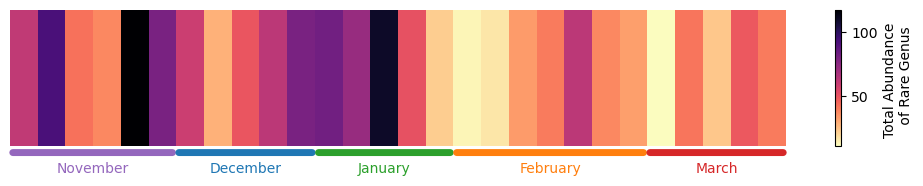

In [27]:
data = long_run_rare_abundance["total_rare_abundance"].to_numpy()

fig, ax = plt.subplots(figsize=(10, 2))

# Create the stripes using imshow
# cmap='RdBu_r' is the standard blue-to-red climate palette
img = ax.imshow(data[np.newaxis, :], cmap="magma_r", aspect="auto")
plt.colorbar(img, label="Total Abundance \n of Rare Genus")
# Remove axes for the clean "stripes" look
ax.set_axis_off()
# ax.yaxis.set_visible(False)


def add_span_label(ax, start, end, label, y_pos=-0.05, color="red"):
    ax.annotate(
        "",
        xy=(start, y_pos),
        xycoords="axes fraction",
        xytext=(end, y_pos),
        textcoords="axes fraction",
        arrowprops=dict(arrowstyle="-", color=color, lw=5),
    )
    ax.text(
        (start + end) / 2,
        y_pos - 0.15,
        label,
        transform=ax.transAxes,
        ha="center",
        color=color,
    )


add_span_label(ax, 0, 0.213, "November", color="tab:purple")
add_span_label(ax, 0.214, 0.393, "December", color="tab:blue")
add_span_label(ax, 0.394, 0.571, "January", color="tab:green")
add_span_label(ax, 0.572, 0.82, "February", color="tab:orange")
add_span_label(ax, 0.821, 1, "March", color="tab:red")

plt.tight_layout()

plt.show()

In [28]:
long_run_rare_abundance.to_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Output_for_Luke/For_talk/recalled_Total_abundance_of_rare_species.csv",
)

In [29]:
long_run_data

,timepoint,n_samples,n_unique_rare_genus,n_rare_occurrences,first_date,last_date,timepoint plotter
0,t01,8,22,32,11/1/23,11/1/23,1
1,t02,8,41,57,11/7/23,11/7/23,2
2,t03,8,18,24,11/14/23,11/14/23,3
3,t04,8,27,29,11/17/23,11/17/23,4
4,t05,7,30,32,11/21/23,11/21/23,5
5,t06,8,26,31,11/28/23,11/28/23,6
6,t07,7,33,38,12/1/23,12/1/23,7
7,t08,6,14,15,12/5/23,12/5/23,8
8,t09,7,23,34,12/8/23,12/8/23,9
9,t10,8,30,40,12/12/23,12/12/23,10


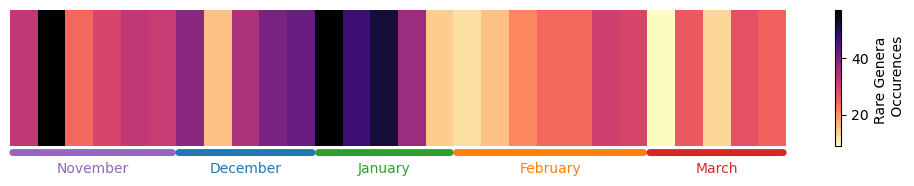

In [30]:
data = long_run_data["n_rare_occurrences"].to_numpy()

fig, ax = plt.subplots(figsize=(10, 2))

# Create the stripes using imshow
# cmap='RdBu_r' is the standard blue-to-red climate palette
img = ax.imshow(data[np.newaxis, :], cmap="magma_r", aspect="auto")
plt.colorbar(img, label="Rare Genera \n Occurences")
# Remove axes for the clean "stripes" look
ax.set_axis_off()
# ax.yaxis.set_visible(False)


def add_span_label(ax, start, end, label, y_pos=-0.05, color="red"):
    ax.annotate(
        "",
        xy=(start, y_pos),
        xycoords="axes fraction",
        xytext=(end, y_pos),
        textcoords="axes fraction",
        arrowprops=dict(arrowstyle="-", color=color, lw=5),
    )
    ax.text(
        (start + end) / 2,
        y_pos - 0.15,
        label,
        transform=ax.transAxes,
        ha="center",
        color=color,
    )


add_span_label(ax, 0, 0.213, "November", color="tab:purple")
add_span_label(ax, 0.214, 0.393, "December", color="tab:blue")
add_span_label(ax, 0.394, 0.571, "January", color="tab:green")
add_span_label(ax, 0.572, 0.82, "February", color="tab:orange")
add_span_label(ax, 0.821, 1, "March", color="tab:red")

plt.tight_layout()

plt.show()

In [31]:
# long_run_data.to_csv(
#     "/Users/michael/Data/Luke_terrace_experiment/Output_for_Luke/For_talk/Rare_genus_occurancesand_n_unique_rare_genus.csv",
# )

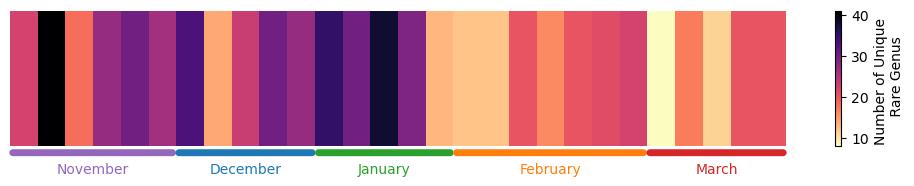

In [32]:
data = long_run_data["n_unique_rare_genus"].to_numpy()

fig, ax = plt.subplots(figsize=(10, 2))

# Create the stripes using imshow
# cmap='RdBu_r' is the standard blue-to-red climate palette
img = ax.imshow(data[np.newaxis, :], cmap="magma_r", aspect="auto")
plt.colorbar(img, label="Number of Unique \n Rare Genus")
# Remove axes for the clean "stripes" look
ax.set_axis_off()
# ax.yaxis.set_visible(False)


def add_span_label(ax, start, end, label, y_pos=-0.05, color="red"):
    ax.annotate(
        "",
        xy=(start, y_pos),
        xycoords="axes fraction",
        xytext=(end, y_pos),
        textcoords="axes fraction",
        arrowprops=dict(arrowstyle="-", color=color, lw=5),
    )
    ax.text(
        (start + end) / 2,
        y_pos - 0.15,
        label,
        transform=ax.transAxes,
        ha="center",
        color=color,
    )


add_span_label(ax, 0, 0.213, "November", color="tab:purple")
add_span_label(ax, 0.214, 0.393, "December", color="tab:blue")
add_span_label(ax, 0.394, 0.571, "January", color="tab:green")
add_span_label(ax, 0.572, 0.82, "February", color="tab:orange")
add_span_label(ax, 0.821, 1, "March", color="tab:red")

plt.tight_layout()

plt.show()

In [33]:
long_run_data

,timepoint,n_samples,n_unique_rare_genus,n_rare_occurrences,first_date,last_date,timepoint plotter
0,t01,8,22,32,11/1/23,11/1/23,1
1,t02,8,41,57,11/7/23,11/7/23,2
2,t03,8,18,24,11/14/23,11/14/23,3
3,t04,8,27,29,11/17/23,11/17/23,4
4,t05,7,30,32,11/21/23,11/21/23,5
5,t06,8,26,31,11/28/23,11/28/23,6
6,t07,7,33,38,12/1/23,12/1/23,7
7,t08,6,14,15,12/5/23,12/5/23,8
8,t09,7,23,34,12/8/23,12/8/23,9
9,t10,8,30,40,12/12/23,12/12/23,10


In [34]:
long_run_core_data = missing_core_by_timepoint.loc[
    ~missing_core_by_timepoint["timepoint"].str.contains("_")
]
long_run_core_data["timepoint plotter"] = (
    long_run_core_data["timepoint"].str.strip("t").astype(int)
)
long_run_core_data

,timepoint,n_samples,n_samples_missing_any_core,total_core_missing,mean_core_missing,first_date,last_date,timepoint plotter
0,t01,8,6,13,1.625000,11/1/23,11/1/23,1
1,t02,8,8,16,2.000000,11/7/23,11/7/23,2
2,t03,8,5,11,1.375000,11/14/23,11/14/23,3
3,t04,8,8,25,3.125000,11/17/23,11/17/23,4
4,t05,8,6,12,1.500000,11/21/23,11/21/23,5
5,t06,8,7,17,2.125000,11/28/23,11/28/23,6
6,t07,8,7,16,2.000000,12/1/23,12/1/23,7
7,t08,8,7,19,2.375000,12/5/23,12/5/23,8
8,t09,8,8,34,4.250000,12/8/23,12/8/23,9
9,t10,8,8,26,3.250000,12/12/23,12/12/23,10


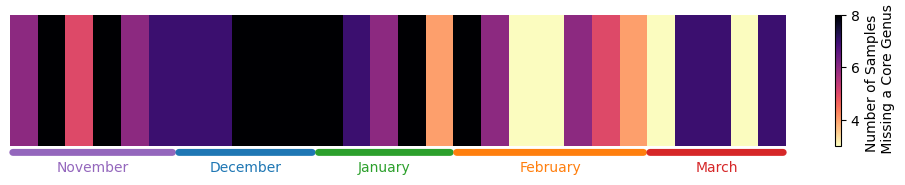

In [35]:
data = long_run_core_data["n_samples_missing_any_core"].to_numpy()

fig, ax = plt.subplots(figsize=(10, 2))

# Create the stripes using imshow
# cmap='RdBu_r' is the standard blue-to-red climate palette
img = ax.imshow(data[np.newaxis, :], cmap="magma_r", aspect="auto")
plt.colorbar(img, label="Number of Samples \n Missing a Core Genus")
# Remove axes for the clean "stripes" look
ax.set_axis_off()
# ax.yaxis.set_visible(False)


def add_span_label(ax, start, end, label, y_pos=-0.05, color="red"):
    ax.annotate(
        "",
        xy=(start, y_pos),
        xycoords="axes fraction",
        xytext=(end, y_pos),
        textcoords="axes fraction",
        arrowprops=dict(arrowstyle="-", color=color, lw=5),
    )
    ax.text(
        (start + end) / 2,
        y_pos - 0.15,
        label,
        transform=ax.transAxes,
        ha="center",
        color=color,
    )


add_span_label(ax, 0, 0.213, "November", color="tab:purple")
add_span_label(ax, 0.214, 0.393, "December", color="tab:blue")
add_span_label(ax, 0.394, 0.571, "January", color="tab:green")
add_span_label(ax, 0.572, 0.82, "February", color="tab:orange")
add_span_label(ax, 0.821, 1, "March", color="tab:red")

plt.tight_layout()

plt.show()

In [36]:
long_run_core_data.to_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Output_for_Luke/For_talk/recalled_Number_samples_missing_core_and_total_number_of_cores_genus_missing.csv",
)

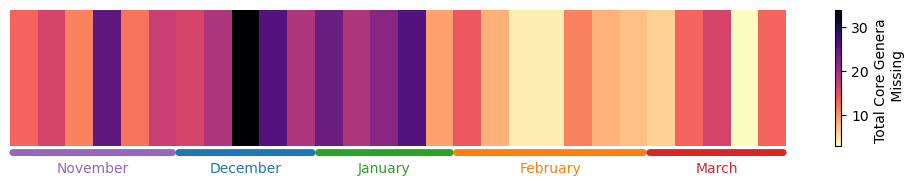

In [37]:
data = long_run_core_data["total_core_missing"].to_numpy()

fig, ax = plt.subplots(figsize=(10, 2))

# Create the stripes using imshow
# cmap='RdBu_r' is the standard blue-to-red climate palette
img = ax.imshow(data[np.newaxis, :], cmap="magma_r", aspect="auto")
plt.colorbar(img, label="Total Core Genera \n Missing")
# Remove axes for the clean "stripes" look
ax.set_axis_off()
# ax.yaxis.set_visible(False)


def add_span_label(ax, start, end, label, y_pos=-0.05, color="red"):
    ax.annotate(
        "",
        xy=(start, y_pos),
        xycoords="axes fraction",
        xytext=(end, y_pos),
        textcoords="axes fraction",
        arrowprops=dict(arrowstyle="-", color=color, lw=5),
    )
    ax.text(
        (start + end) / 2,
        y_pos - 0.15,
        label,
        transform=ax.transAxes,
        ha="center",
        color=color,
    )


add_span_label(ax, 0, 0.213, "November", color="tab:purple")
add_span_label(ax, 0.214, 0.393, "December", color="tab:blue")
add_span_label(ax, 0.394, 0.571, "January", color="tab:green")
add_span_label(ax, 0.572, 0.82, "February", color="tab:orange")
add_span_label(ax, 0.821, 1, "March", color="tab:red")

plt.tight_layout()

plt.show()

In [38]:
## I want to plot a barcode plot of this in python and add month markers at bottom